# 10 — Cohort Retention Analysis

## Objective

This notebook groups customers by the month of their first delivered purchase and measures whether they made another delivered purchase in later calendar months.

The analysis evaluates:

- Customer acquisition cohorts
- Monthly observed repeat-purchase rates
- Cohort retention curves
- Repeat-purchase timing
- Differences between acquisition cohorts

A customer who does not purchase again within the dataset is described as **not observed returning**. This does not prove churn because activity before or after the observation period is unavailable.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.ticker import PercentFormatter

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

DATA_DIR = Path("../data/processed")
IMAGES_DIR = Path("../images/notebook_outputs")

IMAGES_DIR.mkdir(parents=True, exist_ok=True)

COLORS = {
    "primary": "#173F5F",
    "secondary": "#20639B",
    "accent": "#F6C85F",
    "positive": "#3CAEA3",
    "negative": "#ED553B",
    "neutral": "#8A8A8A"
}

order_analytics = pd.read_csv(
    DATA_DIR / "order_analytics.csv",
    parse_dates=["order_purchase_timestamp"]
)

cohort_orders = (
    order_analytics.loc[
        (order_analytics["order_status"] == "delivered")
        & order_analytics["customer_unique_id"].notna(),
        [
            "order_id",
            "customer_unique_id",
            "order_purchase_timestamp",
            "total_payment_value"
        ]
    ]
    .copy()
)

print(
    "Delivered orders represented:",
    f"{len(cohort_orders):,}"
)
print(
    "Customers represented:",
    f"{cohort_orders['customer_unique_id'].nunique():,}"
)
print(
    "Delivered-purchase period:",
    cohort_orders["order_purchase_timestamp"].min().date(),
    "to",
    cohort_orders["order_purchase_timestamp"].max().date()
)

Delivered orders represented: 96,478
Customers represented: 93,358
Delivered-purchase period: 2016-09-15 to 2018-08-29


In [2]:
cohort_orders["purchase_month"] = (
    cohort_orders["order_purchase_timestamp"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

customer_cohorts = (
    cohort_orders
    .groupby("customer_unique_id", as_index=False)
    .agg(
        cohort_month=("purchase_month", "min")
    )
)

customer_month_activity = (
    cohort_orders[
        [
            "customer_unique_id",
            "purchase_month"
        ]
    ]
    .drop_duplicates()
    .merge(
        customer_cohorts,
        on="customer_unique_id",
        how="left",
        validate="many_to_one"
    )
)

customer_month_activity["cohort_index"] = (
    (
        customer_month_activity["purchase_month"].dt.year
        - customer_month_activity["cohort_month"].dt.year
    ) * 12
    + (
        customer_month_activity["purchase_month"].dt.month
        - customer_month_activity["cohort_month"].dt.month
    )
)

cohort_sizes = (
    customer_cohorts
    .groupby("cohort_month", as_index=False)
    .agg(
        cohort_customers=("customer_unique_id", "nunique")
    )
)

cohort_validation = pd.DataFrame([
    {
        "validation_check": "Customer cohort assignments",
        "result": len(customer_cohorts),
        "expected": cohort_orders[
            "customer_unique_id"
        ].nunique()
    },
    {
        "validation_check": "Duplicate cohort assignments",
        "result": customer_cohorts[
            "customer_unique_id"
        ].duplicated().sum(),
        "expected": 0
    },
    {
        "validation_check": "Customers represented by cohort sizes",
        "result": cohort_sizes[
            "cohort_customers"
        ].sum(),
        "expected": len(customer_cohorts)
    },
    {
        "validation_check": "Negative cohort indexes",
        "result": (
            customer_month_activity["cohort_index"] < 0
        ).sum(),
        "expected": 0
    }
])

cohort_validation["status"] = np.where(
    cohort_validation["result"]
    == cohort_validation["expected"],
    "Passed",
    "Failed"
)

display(cohort_validation)

display(
    cohort_sizes.style.format({
        "cohort_month": "{:%Y-%m}",
        "cohort_customers": "{:,.0f}"
    })
)

,validation_check,result,expected,status
0,Customer cohort assignments,93358,93358,Passed
1,Duplicate cohort assignments,0,0,Passed
2,Customers represented by cohort sizes,93358,93358,Passed
3,Negative cohort indexes,0,0,Passed


,cohort_month,cohort_customers
0,2016-09,1
1,2016-10,262
2,2016-12,1
3,2017-01,717
4,2017-02,"1,628"
5,2017-03,"2,503"
6,2017-04,"2,256"
7,2017-05,"3,451"
8,2017-06,"3,037"
9,2017-07,"3,752"


In [6]:
analysis_end_month = (
    cohort_orders["purchase_month"].max()
)

cohort_sizes["maximum_observable_index"] = (
    (
        analysis_end_month.year
        - cohort_sizes["cohort_month"].dt.year
    ) * 12
    + (
        analysis_end_month.month
        - cohort_sizes["cohort_month"].dt.month
    )
)

observed_activity = (
    customer_month_activity
    .groupby(
        [
            "cohort_month",
            "cohort_index"
        ],
        as_index=False
    )
    .agg(
        active_customers=(
            "customer_unique_id",
            "nunique"
        )
    )
)

all_indexes = pd.DataFrame({
    "cohort_index": range(
        cohort_sizes[
            "maximum_observable_index"
        ].max() + 1
    )
})

complete_cohort_grid = (
    cohort_sizes.assign(join_key=1)
    .merge(
        all_indexes.assign(join_key=1),
        on="join_key"
    )
    .drop(columns="join_key")
    .loc[
        lambda frame:
        frame["cohort_index"]
        <= frame["maximum_observable_index"]
    ]
)

cohort_activity = (
    complete_cohort_grid
    .merge(
        observed_activity,
        on=[
            "cohort_month",
            "cohort_index"
        ],
        how="left",
        validate="one_to_one"
    )
)

cohort_activity["active_customers"] = (
    cohort_activity["active_customers"]
    .fillna(0)
    .astype(int)
)

cohort_activity["retention_rate"] = (
    cohort_activity["active_customers"]
    / cohort_activity["cohort_customers"]
)

retention_matrix = (
    cohort_activity
    .pivot(
        index="cohort_month",
        columns="cohort_index",
        values="retention_rate"
    )
    .sort_index()
)

corrected_validation = pd.DataFrame([
    {
        "validation_check": "Duplicate cohort-index combinations",
        "result": cohort_activity[
            ["cohort_month", "cohort_index"]
        ].duplicated().sum(),
        "expected": 0
    },
    {
        "validation_check": "Missing observable retention rates",
        "result": cohort_activity[
            "retention_rate"
        ].isna().sum(),
        "expected": 0
    },
    {
        "validation_check": "Invalid retention rates",
        "result": (
            ~cohort_activity["retention_rate"]
            .between(0, 1)
        ).sum(),
        "expected": 0
    },
    {
        "validation_check": "Cohorts with invalid month-zero rate",
        "result": (
            retention_matrix[0] != 1
        ).sum(),
        "expected": 0
    }
])

corrected_validation["status"] = np.where(
    corrected_validation["result"]
    == corrected_validation["expected"],
    "Passed",
    "Failed"
)

display(corrected_validation)

retention_display = (
    retention_matrix.loc[
        retention_matrix.index >= "2017-01-01"
    ]
    .iloc[:, :13]
    .copy()
)

retention_display.index = (
    retention_display.index.strftime("%Y-%m")
)

retention_display.index.name = "cohort_month"

display(
    retention_display.style.format(
        "{:.2%}",
        na_rep=""
    )
)

,validation_check,result,expected,status
0,Duplicate cohort-index combinations,0,0,Passed
1,Missing observable retention rates,0,0,Passed
2,Invalid retention rates,0,0,Passed
3,Cohorts with invalid month-zero rate,0,0,Passed


cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12
cohort_month,,,,,,,,,,,,,
2017-01,100.00%,0.28%,0.28%,0.14%,0.42%,0.14%,0.42%,0.14%,0.14%,0.00%,0.42%,0.14%,0.70%
2017-02,100.00%,0.18%,0.31%,0.12%,0.43%,0.12%,0.25%,0.18%,0.12%,0.18%,0.12%,0.31%,0.12%
2017-03,100.00%,0.44%,0.36%,0.40%,0.36%,0.16%,0.16%,0.32%,0.32%,0.08%,0.36%,0.12%,0.20%
2017-04,100.00%,0.62%,0.22%,0.18%,0.27%,0.27%,0.35%,0.31%,0.31%,0.18%,0.27%,0.09%,0.04%
2017-05,100.00%,0.46%,0.46%,0.29%,0.29%,0.32%,0.41%,0.14%,0.26%,0.26%,0.26%,0.35%,0.23%
2017-06,100.00%,0.49%,0.40%,0.43%,0.30%,0.40%,0.36%,0.23%,0.13%,0.20%,0.30%,0.36%,0.16%
2017-07,100.00%,0.53%,0.35%,0.24%,0.29%,0.21%,0.32%,0.11%,0.19%,0.27%,0.21%,0.29%,0.13%
2017-08,100.00%,0.69%,0.35%,0.27%,0.35%,0.52%,0.30%,0.27%,0.15%,0.15%,0.25%,0.20%,0.12%
2017-09,100.00%,0.70%,0.55%,0.27%,0.45%,0.22%,0.22%,0.25%,0.27%,0.17%,0.25%,0.07%,


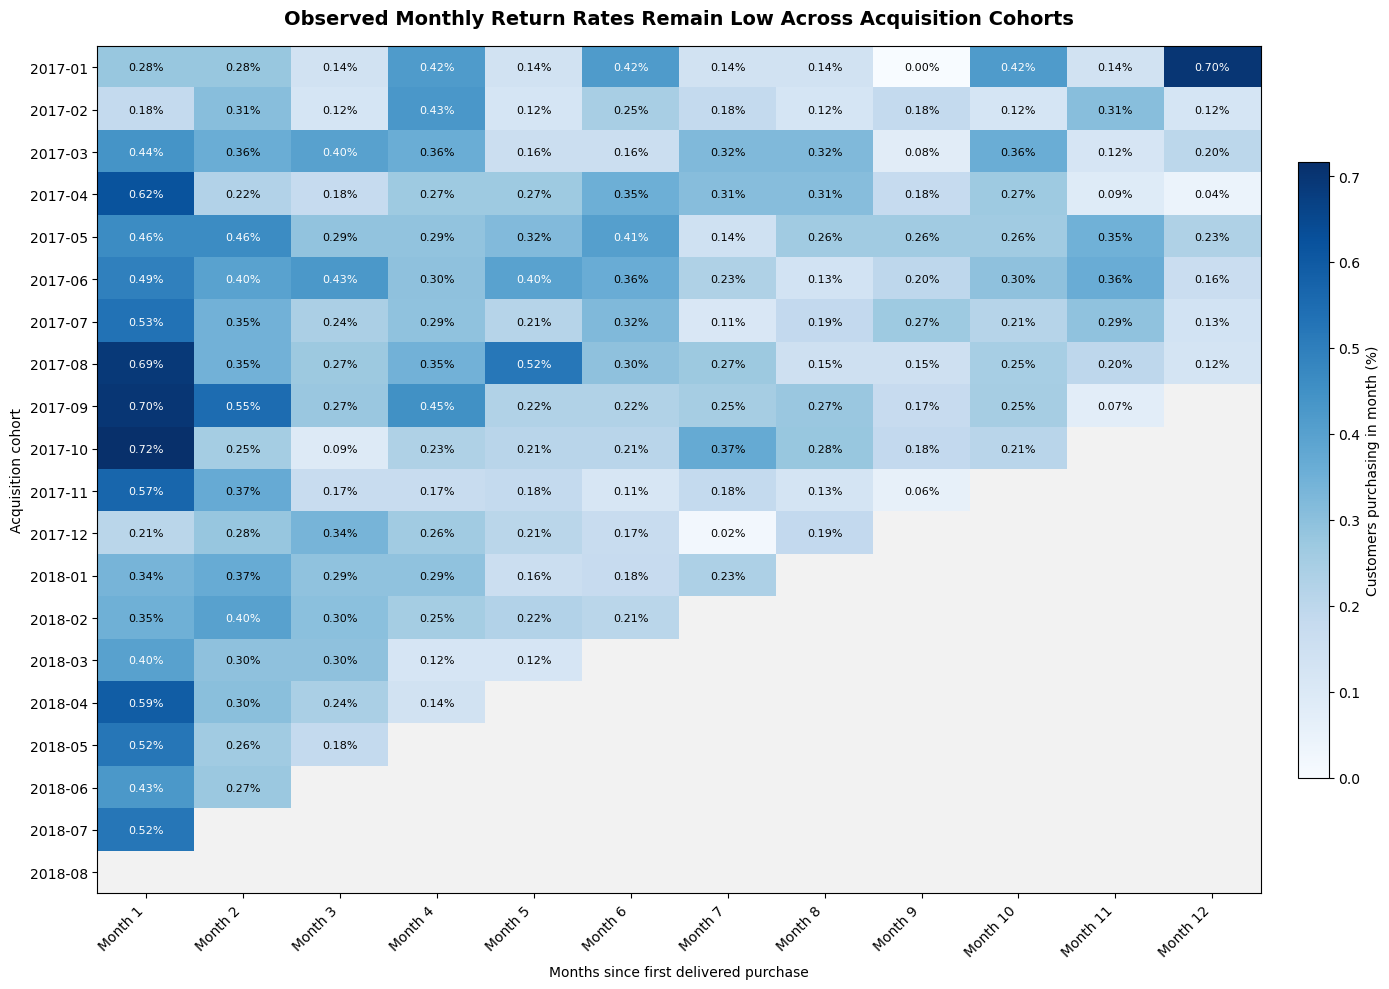

In [7]:
retention_heatmap = (
    retention_matrix.loc[
        retention_matrix.index >= "2017-01-01",
        1:12
    ]
    * 100
)

heatmap_values = retention_heatmap.to_numpy()

cmap = plt.cm.Blues.copy()
cmap.set_bad(color="#F2F2F2")

fig, ax = plt.subplots(figsize=(14, 10))

image = ax.imshow(
    heatmap_values,
    aspect="auto",
    cmap=cmap,
    vmin=0,
    vmax=np.nanmax(heatmap_values)
)

ax.set_xticks(
    np.arange(len(retention_heatmap.columns))
)
ax.set_xticklabels(
    [
        f"Month {column}"
        for column in retention_heatmap.columns
    ]
)

ax.set_yticks(
    np.arange(len(retention_heatmap.index))
)
ax.set_yticklabels(
    retention_heatmap.index.strftime("%Y-%m")
)

for row_index in range(heatmap_values.shape[0]):
    for column_index in range(
        heatmap_values.shape[1]
    ):
        value = heatmap_values[
            row_index,
            column_index
        ]

        if not np.isnan(value):
            text_color = (
                "white"
                if value
                > np.nanmax(heatmap_values) * 0.55
                else "black"
            )

            ax.text(
                column_index,
                row_index,
                f"{value:.2f}%",
                ha="center",
                va="center",
                fontsize=8,
                color=text_color
            )

colorbar = fig.colorbar(
    image,
    ax=ax,
    fraction=0.025,
    pad=0.03
)

colorbar.set_label(
    "Customers purchasing in month (%)"
)

ax.set_title(
    "Observed Monthly Return Rates Remain Low Across Acquisition Cohorts",
    fontsize=14,
    fontweight="bold",
    pad=16
)

ax.set_xlabel("Months since first delivered purchase")
ax.set_ylabel("Acquisition cohort")

plt.setp(
    ax.get_xticklabels(),
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.savefig(
    IMAGES_DIR / "cohort_retention_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

***Observation:*** Across acquisition cohorts from January 2017 onward, the share of customers making another delivered purchase in any specific later month generally remains below 0.75%. Blank cells represent follow-up months that were not observable before the dataset ended and must not be interpreted as zero retention.

In [8]:
benchmark_source = cohort_activity.loc[
    cohort_activity["cohort_month"] >= "2017-01-01"
].copy()

retention_benchmarks = (
    benchmark_source
    .groupby("cohort_index", as_index=False)
    .agg(
        eligible_cohorts=("cohort_month", "nunique"),
        eligible_customers=("cohort_customers", "sum"),
        active_customers=("active_customers", "sum")
    )
)

retention_benchmarks["weighted_retention_rate"] = (
    retention_benchmarks["active_customers"]
    / retention_benchmarks["eligible_customers"]
)

retention_benchmarks = (
    retention_benchmarks.loc[
        retention_benchmarks["cohort_index"].between(
            1,
            12
        )
    ]
    .reset_index(drop=True)
)

display(
    retention_benchmarks.style.format({
        "eligible_cohorts": "{:,.0f}",
        "eligible_customers": "{:,.0f}",
        "active_customers": "{:,.0f}",
        "weighted_retention_rate": "{:.2%}"
    })
)

highest_benchmark = retention_benchmarks.loc[
    retention_benchmarks[
        "weighted_retention_rate"
    ].idxmax()
]

lowest_benchmark = retention_benchmarks.loc[
    retention_benchmarks[
        "weighted_retention_rate"
    ].idxmin()
]

print(
    "Highest weighted rate:",
    f"Month {int(highest_benchmark['cohort_index'])}",
    f"({highest_benchmark['weighted_retention_rate']:.2%})"
)

print(
    "Lowest weighted rate:",
    f"Month {int(lowest_benchmark['cohort_index'])}",
    f"({lowest_benchmark['weighted_retention_rate']:.2%})"
)

,cohort_index,eligible_cohorts,eligible_customers,active_customers,weighted_retention_rate
0,1,19,"86,950",420,0.48%
1,2,18,"81,001",273,0.34%
2,3,17,"75,123",192,0.26%
3,4,16,"68,617",176,0.26%
4,5,15,"62,035",140,0.23%
5,6,14,"55,261",128,0.23%
6,7,13,"48,973",102,0.21%
7,8,12,"42,131",86,0.20%
8,9,11,"36,793",59,0.16%
9,10,10,"29,733",75,0.25%


Highest weighted rate: Month 1 (0.48%)
Lowest weighted rate: Month 9 (0.16%)


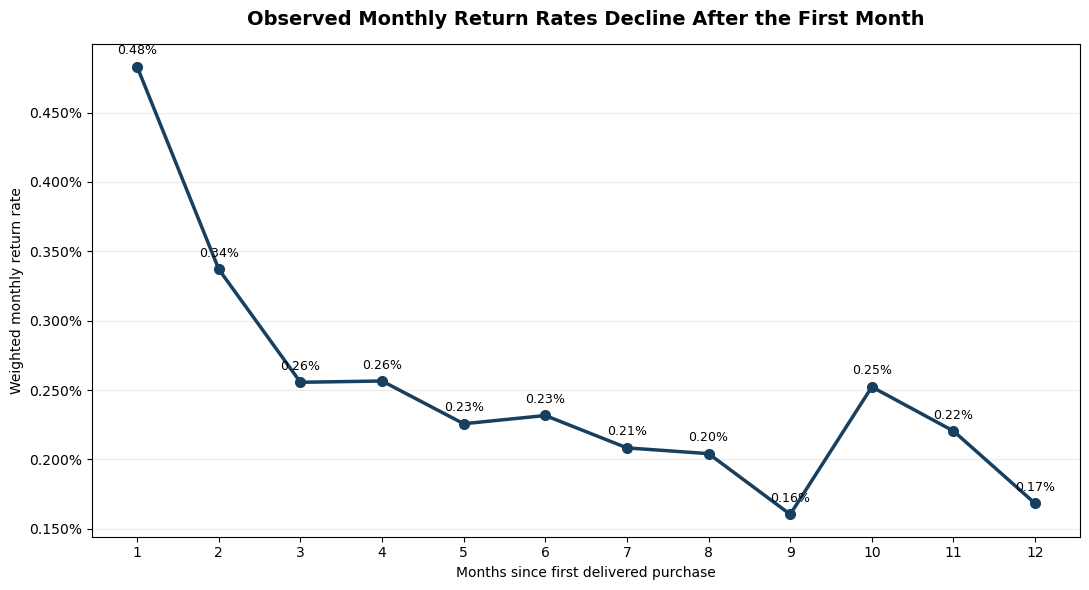

In [9]:
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    retention_benchmarks["cohort_index"],
    retention_benchmarks["weighted_retention_rate"],
    marker="o",
    linewidth=2.5,
    markersize=7,
    color=COLORS["primary"]
)

for _, row in retention_benchmarks.iterrows():
    ax.annotate(
        f"{row['weighted_retention_rate']:.2%}",
        xy=(
            row["cohort_index"],
            row["weighted_retention_rate"]
        ),
        xytext=(0, 9),
        textcoords="offset points",
        ha="center",
        fontsize=9
    )

ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_xticks(
    retention_benchmarks["cohort_index"]
)

ax.set_xlabel("Months since first delivered purchase")
ax.set_ylabel("Weighted monthly return rate")

ax.set_title(
    "Observed Monthly Return Rates Decline After the First Month",
    fontsize=14,
    fontweight="bold",
    pad=14
)

ax.grid(axis="x", visible=False)
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()

plt.savefig(
    IMAGES_DIR / "weighted_monthly_retention_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

***Observation:*** The weighted return rate is highest one month after acquisition at 0.48% and generally declines at longer cohort ages. Because later indexes include fewer eligible cohorts and customers, these values describe observed monthly purchasing rather than a guaranteed long-term retention curve.

In [10]:
return_horizons = [1, 3, 6, 12]

cumulative_return_records = []

for horizon in return_horizons:
    eligible_cohort_months = (
        cohort_sizes.loc[
            (
                cohort_sizes["cohort_month"]
                >= "2017-01-01"
            )
            & (
                cohort_sizes[
                    "maximum_observable_index"
                ] >= horizon
            ),
            "cohort_month"
        ]
    )

    eligible_customers = (
        customer_cohorts.loc[
            customer_cohorts["cohort_month"].isin(
                eligible_cohort_months
            ),
            "customer_unique_id"
        ]
    )

    returning_customers = (
        customer_month_activity.loc[
            (
                customer_month_activity[
                    "cohort_month"
                ].isin(eligible_cohort_months)
            )
            & (
                customer_month_activity[
                    "cohort_index"
                ].between(1, horizon)
            ),
            "customer_unique_id"
        ]
        .nunique()
    )

    cumulative_return_records.append({
        "return_horizon": f"Within {horizon} month"
        + ("s" if horizon > 1 else ""),
        "months_observed": horizon,
        "eligible_cohorts": len(
            eligible_cohort_months
        ),
        "eligible_customers": (
            eligible_customers.nunique()
        ),
        "returning_customers": returning_customers,
        "cumulative_return_rate": (
            returning_customers
            / eligible_customers.nunique()
        )
    })

cumulative_return_summary = pd.DataFrame(
    cumulative_return_records
)

display(
    cumulative_return_summary.style.format({
        "months_observed": "{:,.0f}",
        "eligible_cohorts": "{:,.0f}",
        "eligible_customers": "{:,.0f}",
        "returning_customers": "{:,.0f}",
        "cumulative_return_rate": "{:.2%}"
    })
)

cumulative_validation = pd.DataFrame([
    {
        "validation_check":
            "Returning customers exceeding eligible customers",
        "result": (
            cumulative_return_summary[
                "returning_customers"
            ]
            > cumulative_return_summary[
                "eligible_customers"
            ]
        ).sum(),
        "expected": 0
    },
    {
        "validation_check":
            "Invalid cumulative return rates",
        "result": (
            ~cumulative_return_summary[
                "cumulative_return_rate"
            ].between(0, 1)
        ).sum(),
        "expected": 0
    }
])

cumulative_validation["status"] = np.where(
    cumulative_validation["result"]
    == cumulative_validation["expected"],
    "Passed",
    "Failed"
)

display(cumulative_validation)

,return_horizon,months_observed,eligible_cohorts,eligible_customers,returning_customers,cumulative_return_rate
0,Within 1 month,1,19,"86,950",420,0.48%
1,Within 3 months,3,17,"75,123",790,1.05%
2,Within 6 months,6,14,"55,261",971,1.76%
3,Within 12 months,12,8,"21,401",649,3.03%


,validation_check,result,expected,status
0,Returning customers exceeding eligible customers,0,0,Passed
1,Invalid cumulative return rates,0,0,Passed


In [11]:
fixed_cohort_months = (
    cohort_sizes.loc[
        (
            cohort_sizes["cohort_month"]
            >= "2017-01-01"
        )
        & (
            cohort_sizes[
                "maximum_observable_index"
            ] >= 12
        ),
        "cohort_month"
    ]
)

fixed_population_customers = (
    customer_cohorts.loc[
        customer_cohorts["cohort_month"].isin(
            fixed_cohort_months
        ),
        "customer_unique_id"
    ]
    .unique()
)

fixed_population_size = len(
    fixed_population_customers
)

fixed_cumulative_records = []

for horizon in return_horizons:
    returning_customers = (
        customer_month_activity.loc[
            (
                customer_month_activity[
                    "customer_unique_id"
                ].isin(fixed_population_customers)
            )
            & (
                customer_month_activity[
                    "cohort_index"
                ].between(1, horizon)
            ),
            "customer_unique_id"
        ]
        .nunique()
    )

    fixed_cumulative_records.append({
        "months_observed": horizon,
        "eligible_cohorts": len(
            fixed_cohort_months
        ),
        "eligible_customers": (
            fixed_population_size
        ),
        "returning_customers": (
            returning_customers
        ),
        "cumulative_return_rate": (
            returning_customers
            / fixed_population_size
        )
    })

fixed_cumulative_return = pd.DataFrame(
    fixed_cumulative_records
)

display(
    fixed_cumulative_return.style.format({
        "months_observed": "{:,.0f}",
        "eligible_cohorts": "{:,.0f}",
        "eligible_customers": "{:,.0f}",
        "returning_customers": "{:,.0f}",
        "cumulative_return_rate": "{:.2%}"
    })
)

print(
    "Fixed acquisition cohorts:",
    fixed_cohort_months.min().strftime("%Y-%m"),
    "to",
    fixed_cohort_months.max().strftime("%Y-%m")
)
print(
    "Fixed customer population:",
    f"{fixed_population_size:,}"
)

,months_observed,eligible_cohorts,eligible_customers,returning_customers,cumulative_return_rate
0,1,8,"21,401",109,0.51%
1,3,8,"21,401",234,1.09%
2,6,8,"21,401",416,1.94%
3,12,8,"21,401",649,3.03%


Fixed acquisition cohorts: 2017-01 to 2017-08
Fixed customer population: 21,401


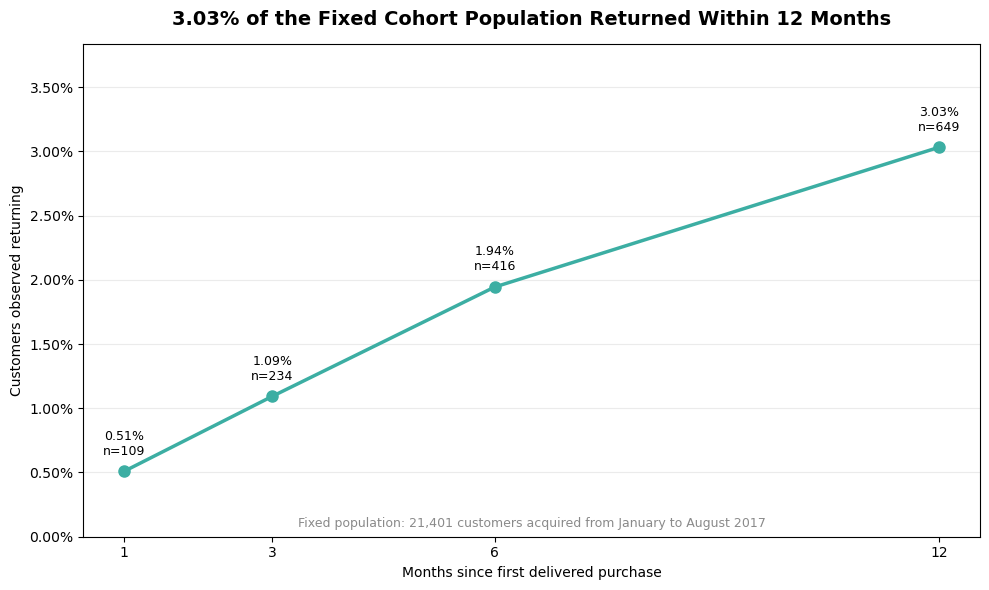

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    fixed_cumulative_return["months_observed"],
    fixed_cumulative_return["cumulative_return_rate"],
    marker="o",
    linewidth=2.5,
    markersize=8,
    color=COLORS["positive"]
)

for _, row in fixed_cumulative_return.iterrows():
    ax.annotate(
        (
            f"{row['cumulative_return_rate']:.2%}\n"
            f"n={int(row['returning_customers']):,}"
        ),
        xy=(
            row["months_observed"],
            row["cumulative_return_rate"]
        ),
        xytext=(0, 12),
        textcoords="offset points",
        ha="center",
        fontsize=9
    )

ax.set_xticks(
    fixed_cumulative_return["months_observed"]
)

ax.yaxis.set_major_formatter(PercentFormatter(1))

ax.set_xlabel("Months since first delivered purchase")
ax.set_ylabel("Customers observed returning")

ax.set_title(
    "3.03% of the Fixed Cohort Population Returned Within 12 Months",
    fontsize=14,
    fontweight="bold",
    pad=14
)

ax.text(
    0.5,
    0.02,
    (
        "Fixed population: 21,401 customers acquired "
        "from January to August 2017"
    ),
    transform=ax.transAxes,
    ha="center",
    fontsize=9,
    color=COLORS["neutral"]
)

ax.set_ylim(
    0,
    fixed_cumulative_return[
        "cumulative_return_rate"
    ].max() + 0.008
)

ax.grid(axis="x", visible=False)
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()

plt.savefig(
    IMAGES_DIR / "fixed_population_cumulative_return.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

***Observation:*** Using the same 21,401 customers at every horizon, the observed cumulative return rate increases from 0.51% within one month to 3.03% within twelve months. Customers not observed returning cannot be classified as churned because purchases outside the dataset are unavailable.

In [13]:
fixed_cohort_comparison = (
    cohort_sizes.loc[
        cohort_sizes["cohort_month"].isin(
            fixed_cohort_months
        ),
        [
            "cohort_month",
            "cohort_customers"
        ]
    ]
    .copy()
)

for horizon in return_horizons:
    returning_by_cohort = (
        customer_month_activity.loc[
            (
                customer_month_activity[
                    "cohort_month"
                ].isin(fixed_cohort_months)
            )
            & (
                customer_month_activity[
                    "cohort_index"
                ].between(1, horizon)
            )
        ]
        .groupby("cohort_month")[
            "customer_unique_id"
        ]
        .nunique()
    )

    fixed_cohort_comparison[
        f"returning_within_{horizon}_months"
    ] = (
        fixed_cohort_comparison["cohort_month"]
        .map(returning_by_cohort)
        .fillna(0)
        .astype(int)
    )

    fixed_cohort_comparison[
        f"return_rate_{horizon}_months"
    ] = (
        fixed_cohort_comparison[
            f"returning_within_{horizon}_months"
        ]
        / fixed_cohort_comparison["cohort_customers"]
    )

display_columns = [
    "cohort_month",
    "cohort_customers",
    "return_rate_1_months",
    "return_rate_3_months",
    "return_rate_6_months",
    "return_rate_12_months"
]

display(
    fixed_cohort_comparison[
        display_columns
    ].style.format({
        "cohort_month": "{:%Y-%m}",
        "cohort_customers": "{:,.0f}",
        "return_rate_1_months": "{:.2%}",
        "return_rate_3_months": "{:.2%}",
        "return_rate_6_months": "{:.2%}",
        "return_rate_12_months": "{:.2%}"
    })
)

cohort_rate_validation = pd.DataFrame([
    {
        "validation_check": "Fixed cohorts represented",
        "result": len(fixed_cohort_comparison),
        "expected": 8
    },
    {
        "validation_check": "Invalid fixed-cohort return rates",
        "result": sum(
            (
                ~fixed_cohort_comparison[
                    f"return_rate_{horizon}_months"
                ].between(0, 1)
            ).sum()
            for horizon in return_horizons
        ),
        "expected": 0
    }
])

cohort_rate_validation["status"] = np.where(
    cohort_rate_validation["result"]
    == cohort_rate_validation["expected"],
    "Passed",
    "Failed"
)

display(cohort_rate_validation)

,cohort_month,cohort_customers,return_rate_1_months,return_rate_3_months,return_rate_6_months,return_rate_12_months
3,2017-01,717,0.28%,0.70%,1.67%,2.79%
4,2017-02,"1,628",0.18%,0.61%,1.41%,2.33%
5,2017-03,"2,503",0.44%,1.16%,1.76%,2.88%
6,2017-04,"2,256",0.62%,1.02%,1.86%,3.06%
7,2017-05,"3,451",0.46%,1.16%,2.00%,3.22%
8,2017-06,"3,037",0.49%,1.22%,2.07%,3.33%
9,2017-07,"3,752",0.53%,1.07%,1.87%,2.91%
10,2017-08,"4,057",0.69%,1.23%,2.29%,3.18%


,validation_check,result,expected,status
0,Fixed cohorts represented,8,8,Passed
1,Invalid fixed-cohort return rates,0,0,Passed


In [14]:
final_validation = pd.DataFrame([
    {
        "validation_check": "Customers assigned to cohorts",
        "result": len(customer_cohorts),
        "expected": cohort_orders[
            "customer_unique_id"
        ].nunique()
    },
    {
        "validation_check": "Duplicate customer assignments",
        "result": customer_cohorts[
            "customer_unique_id"
        ].duplicated().sum(),
        "expected": 0
    },
    {
        "validation_check": "Month-zero customers represented",
        "result": cohort_activity.loc[
            cohort_activity["cohort_index"] == 0,
            "active_customers"
        ].sum(),
        "expected": len(customer_cohorts)
    },
    {
        "validation_check": "Missing observable retention rates",
        "result": cohort_activity[
            "retention_rate"
        ].isna().sum(),
        "expected": 0
    },
    {
        "validation_check": "Invalid retention rates",
        "result": (
            ~cohort_activity["retention_rate"]
            .between(0, 1)
        ).sum(),
        "expected": 0
    },
    {
        "validation_check": "Fixed-population customers",
        "result": fixed_population_size,
        "expected": 21_401
    },
    {
        "validation_check": "Fixed 12-month returning customers",
        "result": int(
            fixed_cumulative_return.loc[
                fixed_cumulative_return[
                    "months_observed"
                ] == 12,
                "returning_customers"
            ].iloc[0]
        ),
        "expected": 649
    },
    {
        "validation_check": "Fixed cohorts represented",
        "result": len(fixed_cohort_comparison),
        "expected": 8
    }
])

final_validation["status"] = np.where(
    final_validation["result"]
    == final_validation["expected"],
    "Passed",
    "Failed"
)

display(final_validation)

,validation_check,result,expected,status
0,Customers assigned to cohorts,93358,93358,Passed
1,Duplicate customer assignments,0,0,Passed
2,Month-zero customers represented,93358,93358,Passed
3,Missing observable retention rates,0,0,Passed
4,Invalid retention rates,0,0,Passed
5,Fixed-population customers,21401,21401,Passed
6,Fixed 12-month returning customers,649,649,Passed
7,Fixed cohorts represented,8,8,Passed


In [15]:
retention_matrix_export = (
    retention_matrix
    .reset_index()
)

export_files = {
    "customer_cohort_assignments.csv":
        customer_cohorts,
    "customer_month_activity.csv":
        customer_month_activity,
    "cohort_monthly_retention.csv":
        cohort_activity,
    "cohort_retention_matrix.csv":
        retention_matrix_export,
    "weighted_retention_benchmarks.csv":
        retention_benchmarks,
    "cumulative_return_summary.csv":
        cumulative_return_summary,
    "fixed_population_cumulative_return.csv":
        fixed_cumulative_return,
    "fixed_cohort_comparison.csv":
        fixed_cohort_comparison,
    "cohort_retention_validation.csv":
        final_validation
}

for filename, dataframe in export_files.items():
    dataframe.to_csv(
        DATA_DIR / filename,
        index=False
    )

all_files_created = all(
    (DATA_DIR / filename).exists()
    for filename in export_files
)

print(
    "Cohort-analysis files exported:",
    len(export_files)
)
print(
    "All cohort-analysis files created:",
    all_files_created
)

Cohort-analysis files exported: 9
All cohort-analysis files created: True


## Conclusion

***Key findings:***

- The analysis assigns 93,358 customers to monthly acquisition cohorts using their first delivered purchase.
- Weighted Month-1 observed return is 0.48%, declining to 0.16% by Month 9 before fluctuating slightly.
- Using a fixed population of 21,401 customers acquired from January through August 2017, cumulative return reaches 1.09% within three months, 1.94% within six months, and 3.03% within twelve months.
- Across the eight fully observed cohorts, twelve-month return rates range from 2.33% to 3.33%.
- Observable zero-return months were separated from future months unavailable before the dataset ended.

***Interpretation:*** Later purchasing is uncommon within the available dataset. Customers not observed returning are not classified as churned because purchases before or after the observation window are unavailable, and Olist is not documented here as a subscription business.

***Outputs:*** Customer cohort assignments, monthly activity, retention matrices, weighted benchmarks, fixed-population comparisons, and validation results were exported for reporting.